In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
try:
    import seaborn as sns
except ImportError:
    sns = None


import pickle

# Processing TEXT

In [3]:
import os
import re
import pandas as pd



from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report



if sns is not None:
    sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

base_dir = '/content/drive/MyDrive/VMI_PROJET/data/datasetSujet3/content/dataset'

def extract_label_from_name(filename):
    matches = re.findall(r'\(([^)]*)\)', filename)
    if len(matches) >= 4:
        if matches[3] == '1':
            return 'homme'
        elif matches[3] == '2':
            return 'femme'
    return None

def load_split(split_name):
    split_dir = os.path.join(base_dir, split_name)
    data = []
    for root, _, files in os.walk(split_dir):
        for f in files:
            if f.endswith('.txt'):
                label = extract_label_from_name(f)
                if label:
                    data.append({
                        'path': os.path.join(root, f),
                        'label': label
                    })
    return pd.DataFrame(data)

def read_text(path):
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        return f.read()

train_df = load_split('train')
val_df = load_split('val')
test_df = load_split('test')

for df in [train_df, val_df, test_df]:
    df['text'] = df['path'].apply(read_text)


print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print("\nDistribution des classes:")
print("Train:\n", train_df['label'].value_counts())
print("Val:\n", val_df['label'].value_counts())
print("Test:\n", test_df['label'].value_counts())



Train: 852 | Val: 284 | Test: 285

Distribution des classes:
Train:
 label
femme    492
homme    360
Name: count, dtype: int64
Val:
 label
femme    164
homme    120
Name: count, dtype: int64
Test:
 label
femme    165
homme    120
Name: count, dtype: int64


# TF IDF, Vectorizer

In [4]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

le = LabelEncoder()
train_df['label_encoded'] = le.fit_transform(train_df['label'])
val_df['label_encoded'] = le.transform(val_df['label'])
test_df['label_encoded'] = le.transform(test_df['label'])

print(f"Classes encodées: {dict(zip(le.classes_, range(len(le.classes_))))}")

tfidf = TfidfVectorizer(max_features=40000, min_df=2, max_df=0.85, ngram_range=(1, 1))

X_train = tfidf.fit_transform(train_df['text']).toarray().astype(np.float32)
X_val = tfidf.transform(val_df['text']).toarray().astype(np.float32)
X_test = tfidf.transform(test_df['text']).toarray().astype(np.float32)

y_train = train_df['label_encoded'].values
y_val = val_df['label_encoded'].values
y_test = test_df['label_encoded'].values

print(f"Forme X_train: {X_train.shape}")
print(f"Vocabulaire TF-IDF: {len(tfidf.get_feature_names_out())} mots")



Classes encodées: {'femme': 0, 'homme': 1}
Forme X_train: (852, 40000)
Vocabulaire TF-IDF: 40000 mots


In [49]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader


class MLPNet(nn.Module):
    def __init__(self, input_dim, hidden_layers=(64, 32), output_dim=2):
        super(MLPNet, self).__init__()
        layers = []
        current_dim = input_dim

        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(current_dim, hidden_dim))
            layers.append(nn.ReLU())
            current_dim = hidden_dim

        layers.append(nn.Linear(current_dim, output_dim))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


In [54]:
BATCH_SIZE = 16
EPOCHS = 5
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_dataset = TensorDataset(
    torch.from_numpy(X_train),
    torch.from_numpy(y_train).long()
)
val_dataset = TensorDataset(
    torch.from_numpy(X_val),
    torch.from_numpy(y_val).long()
)
test_dataset = TensorDataset(
    torch.from_numpy(X_test),
    torch.from_numpy(y_test).long()
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

model = MLPNet(input_dim=X_train.shape[1], hidden_layers=(64, 32), output_dim=2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

print(model)
print(f'Using device: {device}')


MLPNet(
  (network): Sequential(
    (0): Linear(in_features=40000, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=2, bias=True)
  )
)
Using device: cuda


In [55]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.set_grad_enabled(is_train):
        for features, labels in loader:
            features = features.to(device)
            labels = labels.to(device)

            logits = model(features)
            loss = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_samples += batch_size

    return total_loss / total_samples, total_correct / total_samples


history = []

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, criterion)

    history.append({
        'epoch': epoch,
        'train_loss': train_loss,
        'train_acc': train_acc,
        'val_loss': val_loss,
        'val_acc': val_acc,
    })

    print(
        f'Epoch {epoch:02d}/{EPOCHS} | '
        f'train_loss={train_loss:.4f} train_acc={train_acc:.4f} | '
        f'val_loss={val_loss:.4f} val_acc={val_acc:.4f}'
    )

history_df = pd.DataFrame(history)


Epoch 01/5 | train_loss=0.6478 train_acc=0.6526 | val_loss=0.5512 val_acc=0.8275
Epoch 02/5 | train_loss=0.3526 train_acc=0.9261 | val_loss=0.3478 val_acc=0.8345
Epoch 03/5 | train_loss=0.0844 train_acc=0.9906 | val_loss=0.3333 val_acc=0.8486
Epoch 04/5 | train_loss=0.0234 train_acc=1.0000 | val_loss=0.3355 val_acc=0.8451
Epoch 05/5 | train_loss=0.0117 train_acc=1.0000 | val_loss=0.3503 val_acc=0.8380


Test loss: 0.3004 | Test accuracy: 0.8632
              precision    recall  f1-score   support

       femme       0.87      0.90      0.88       165
       homme       0.85      0.82      0.83       120

    accuracy                           0.86       285
   macro avg       0.86      0.86      0.86       285
weighted avg       0.86      0.86      0.86       285



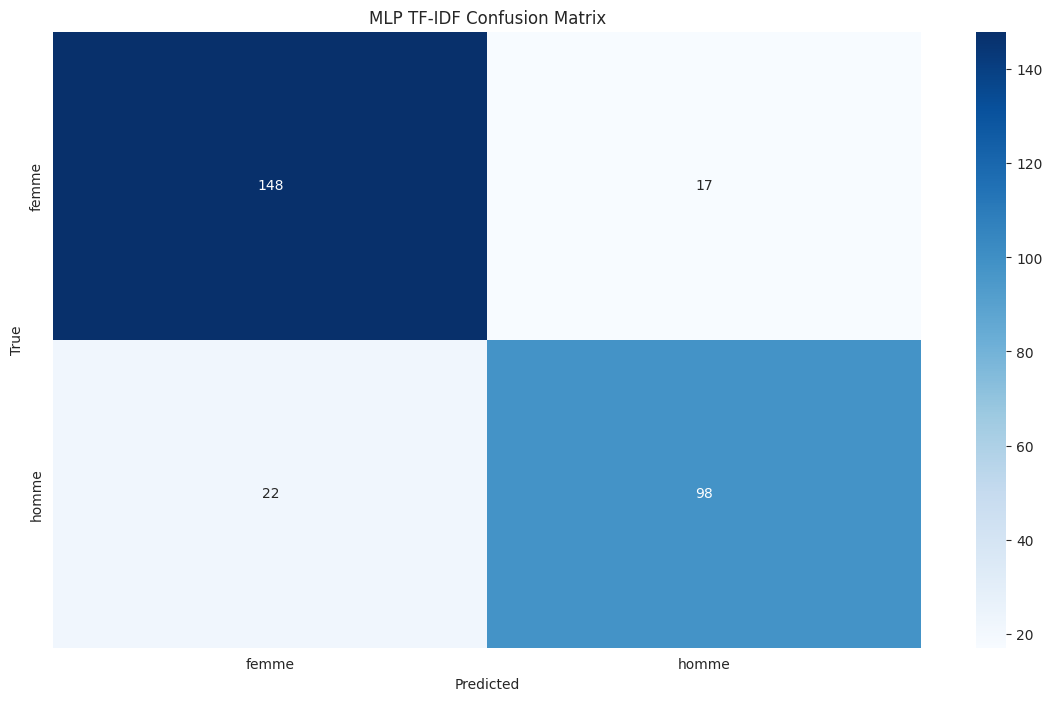

In [56]:
test_loss, test_acc = run_epoch(model, test_loader, criterion)
print(f'Test loss: {test_loss:.4f} | Test accuracy: {test_acc:.4f}')

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for features, labels in test_loader:
        logits = model(features.to(device))
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=le.classes_))

cm = confusion_matrix(all_labels, all_preds)

if sns is not None:
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
else:
    plt.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.colorbar()
    plt.xticks(np.arange(len(le.classes_)), le.classes_)
    plt.yticks(np.arange(len(le.classes_)), le.classes_)
    for row in range(cm.shape[0]):
        for col in range(cm.shape[1]):
            plt.text(col, row, cm[row, col], ha='center', va='center')

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('MLP TF-IDF Confusion Matrix')
plt.show()
